# 02 — Data Ingestion and Preprocessing

Demonstrates the memory-efficient two-pass raw-data ingestion
(`src/ingest.py`) and the per-square feature engineering used by the
tree-based model (`src/preprocessor.py`). See `scripts/build_dataset.py` for
the full, non-interactive pipeline run over the whole archive.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import pandas as pd

from src.utils import load_config
from src.ingest import list_raw_files, naive_load_single_file, optimized_load_single_file

cfg = load_config("config.yaml")

## 1. Memory-efficient loading: naive vs. optimized (single day file)

In [2]:
pd.read_csv("results/tables/memory_benchmark.csv")
# Peak RSS was measured out-of-process with `/usr/bin/time -l`; see
# scripts/benchmark_memory.py and the README/report for methodology.
# The cell below just demonstrates output-shape difference, not peak memory.
path = f'{cfg["data"]["raw_dir"]}/sms-call-internet-mi-2013-11-01.txt'
naive_df = naive_load_single_file(path)
optimized_df = optimized_load_single_file(path)
print("naive shape:", naive_df.shape)
print("optimized (aggregated) shape:", optimized_df.shape)

naive shape: (4842625, 8)
optimized (aggregated) shape: (10000, 2)


## 2. Target-square time series (already extracted by Stage 1)

In [3]:
series_df = pd.read_csv(cfg["data"]["target_series_path"], parse_dates=["timestamp"])
series_df.head()

,square_id,internet,timestamp
0,4159,224.80853,2013-10-31 23:00:00
1,4159,183.50499,2013-10-31 23:10:00
2,4159,204.43130,2013-10-31 23:20:00
3,4159,212.37405,2013-10-31 23:30:00
4,4159,195.76800,2013-10-31 23:40:00


## 3. Feature engineering for the tree-based model (XGBoost)

In [4]:
from src.preprocessor import add_lag_features, add_rolling_features, add_time_features, fourier_terms

square_id = series_df["square_id"].iloc[0]
s = series_df[series_df["square_id"] == square_id].set_index("timestamp")["internet"].asfreq(cfg["data"]["frequency"])
s = s.interpolate("linear").bfill().ffill()

feat_df = s.to_frame("internet")
feat_df = add_time_features(feat_df)
feat_df = add_lag_features(feat_df, "internet", cfg["preprocessing"]["lag_features"])
feat_df = add_rolling_features(feat_df, "internet", cfg["preprocessing"]["rolling_windows"])
feat_df = feat_df.dropna()
feat_df.head()

,internet,hour,day_of_week,day_of_month,month,is_weekend,internet_lag_1,internet_lag_2,internet_lag_3,internet_lag_6,...,internet_lag_72,internet_lag_144,internet_lag_288,internet_lag_1008,internet_roll_mean_6,internet_roll_std_6,internet_roll_mean_18,internet_roll_std_18,internet_roll_mean_144,internet_roll_std_144
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-11-07 23:00:00,269.72700,23,3,7,11,0,245.98717,257.60828,218.78387,252.35710,...,648.73175,268.80502,233.51045,224.80853,256.788355,25.628454,271.697522,30.630843,384.033860,204.655852
2013-11-07 23:10:00,261.59488,23,3,7,11,0,269.72700,245.98717,257.60828,295.82266,...,613.28490,284.98694,185.16748,183.50499,259.683338,26.006058,270.793983,30.423596,384.040262,204.652236
2013-11-07 23:20:00,299.04788,23,3,7,11,0,261.59488,269.72700,245.98717,270.17105,...,765.91500,256.80502,207.55667,204.43130,253.978708,19.410934,268.554851,29.467786,383.877817,204.740675
2013-11-07 23:30:00,206.14488,23,3,7,11,0,299.04788,261.59488,269.72700,218.78387,...,744.44086,217.61108,242.95944,212.37405,258.791513,26.510306,270.270159,30.330216,384.171171,204.587537
2013-11-07 23:40:00,198.41950,23,3,7,11,0,206.14488,299.04788,261.59488,257.60828,...,704.68524,221.46338,196.88243,195.76800,256.685015,30.523480,263.022828,29.110408,384.091544,204.655037


## 4. Fourier seasonal regressors used by the SARIMAX baseline

<Axes: title={'center': 'Fourier daily-seasonality regressors (2 days shown)'}, xlabel='timestamp'>

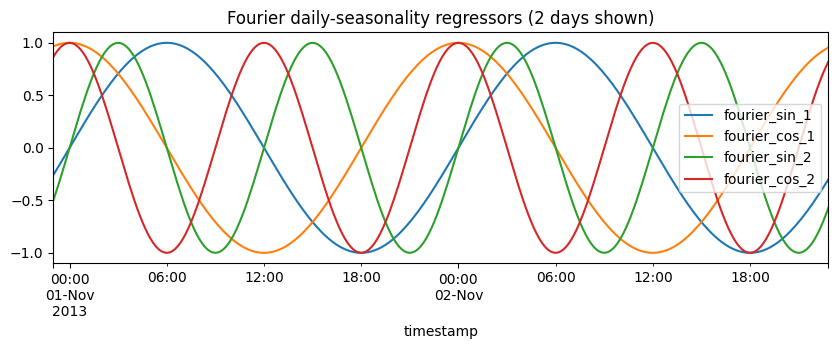

In [5]:
fourier = fourier_terms(s.index[:288], period=cfg["models"]["arima"]["fourier_period"],
                        n_harmonics=cfg["models"]["arima"]["fourier_harmonics"])
fourier.plot(figsize=(10, 3), title="Fourier daily-seasonality regressors (2 days shown)")